# Fake News Detection using Machine Learning

## Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the Fake and Real News dataset. The analysis includes understanding the dataset structure, checking for missing values, merging the datasets, and visualizing important patterns before building machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 1: Import Required Libraries

The following Python libraries are imported for data manipulation, visualization, and machine learning tasks.

- **Pandas** – Data manipulation and analysis
- **NumPy** – Numerical computations
- **Matplotlib** – Data visualization
- **Seaborn** – Statistical visualization

In [2]:
fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")

print("Fake dataset shape:", fake.shape)
print("True dataset shape:", true.shape)

Fake dataset shape: (23481, 4)
True dataset shape: (21417, 4)


## Step 2: Load the Dataset

The project uses two datasets:

- **Fake.csv** – Contains fake news articles.
- **True.csv** – Contains genuine news articles.

Both datasets are loaded into separate Pandas DataFrames for analysis.

In [3]:
fake.head()


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


## Step 3: Preview the Dataset

The `head()` function is used to display the first five rows of each dataset. This helps us understand the dataset structure and available features.

In [4]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


## Step 4: Dataset Information

The `info()` function provides:

- Number of records
- Number of columns
- Data types
- Memory usage
- Missing values

In [5]:
fake.info()

<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 60.4 MB


## Step 5: Missing Value Analysis

Before preprocessing, it is important to verify whether the dataset contains any missing values.

Missing values can negatively impact machine learning model performance.

In [6]:
true.info()

<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 51.6 MB


## Step 6: Assign Labels

Since this is a supervised machine learning problem, each news article is assigned a target label.

- Fake News → **0**
- Real News → **1**

In [7]:
print(fake.isnull().sum())
print("-" * 30)
print(true.isnull().sum())

title      0
text       0
subject    0
date       0
dtype: int64
------------------------------
title      0
text       0
subject    0
date       0
dtype: int64


## Step 7: Merge the Datasets

The fake and real news datasets are combined into a single DataFrame.

This makes preprocessing and model training easier.

In [8]:
fake["label"] = 0
true["label"] = 1

## Step 8: Shuffle the Dataset

The combined dataset is shuffled randomly to remove any ordering bias.

Random shuffling ensures that fake and real news articles are mixed before training machine learning models.

In [9]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [10]:
df = pd.concat([fake, true], ignore_index=True)

print(df.shape)

(44898, 5)


### Observation

The merged dataset now contains both fake and real news articles.

A new column named **label** identifies whether a news article is fake (`0`) or real (`1`).

The dataset has also been shuffled successfully.

In [11]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


## Step 9: Analyze the Distribution of Fake and Real News

Before training a machine learning model, it is important to understand the distribution of the target classes.

The dataset contains two classes:

- **0** → Fake News
- **1** → Real News

A balanced dataset helps improve the reliability of machine learning models.

In [12]:
df["label"].value_counts()

label
0    23481
1    21417
Name: count, dtype: int64

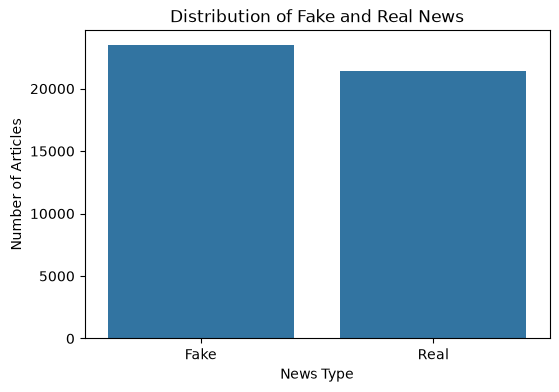

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.xticks([0,1], ["Fake", "Real"])
plt.title("Distribution of Fake and Real News")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")

plt.show()

### Observation

The dataset contains both fake and real news articles. Although the number of fake articles is slightly higher than the number of real articles, the dataset is reasonably balanced. Therefore, no additional balancing techniques are required before training the machine learning models.

## Step 10: Analyze the Distribution of News Subjects

Each news article belongs to a particular subject category. Analyzing these categories helps us understand the diversity of the dataset and identify which topics are most common.

In [14]:
df["subject"].value_counts()

subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

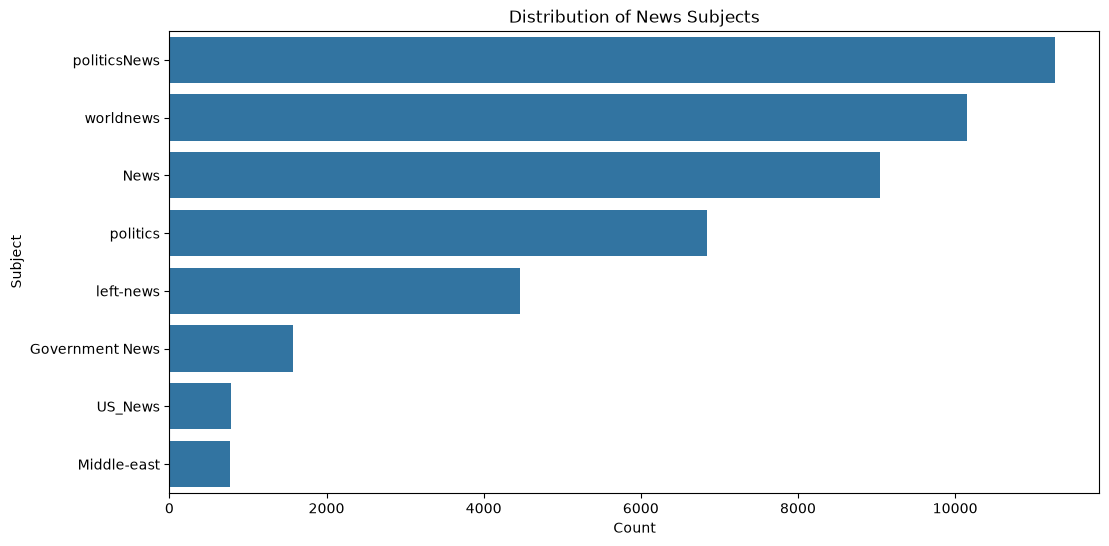

In [15]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="subject",
    data=df,
    order=df["subject"].value_counts().index
)

plt.title("Distribution of News Subjects")
plt.xlabel("Count")
plt.ylabel("Subject")

plt.show()

### Observation

The dataset contains news articles from multiple subject categories such as politics, world news, government news, and others. The distribution of articles is not uniform across all subjects. Political news appears most frequently, indicating that the dataset is heavily focused on political content.


In [16]:
df["text_length"] = df["text"].apply(len)

df[["text", "text_length"]].head()

,text,text_length
0,"21st Century Wire says Ben Stein, reputable pr...",1028
1,WASHINGTON (Reuters) - U.S. President Donald T...,4820
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,1848
3,"On Monday, Donald Trump once again embarrassed...",1244
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",3137


## Step 11: Analyze News Article Length

The length of each news article is calculated using the number of characters present in the article text.

This feature helps us understand how lengthy the news articles are and whether fake and real news differ in article length.

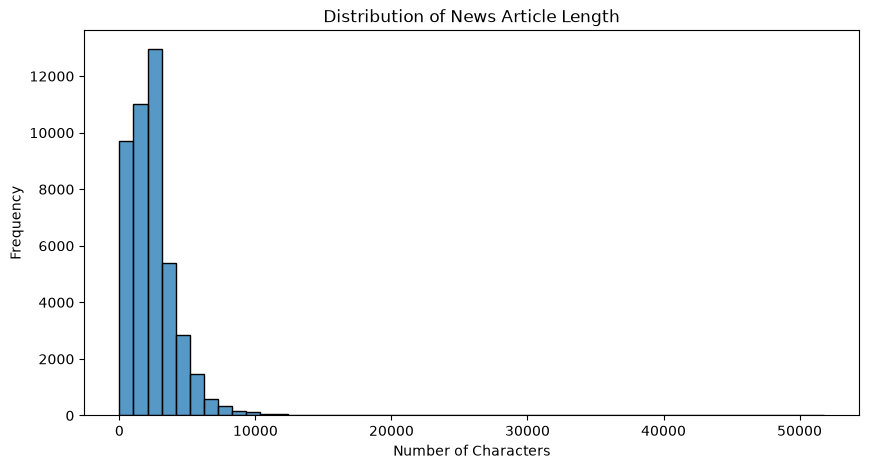

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(df["text_length"], bins=50)

plt.title("Distribution of News Article Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

### Observation

The histogram shows the distribution of article lengths across the entire dataset. Most news articles fall within a specific range of character counts, while a few articles are significantly longer. This indicates the presence of some outliers in terms of article length.

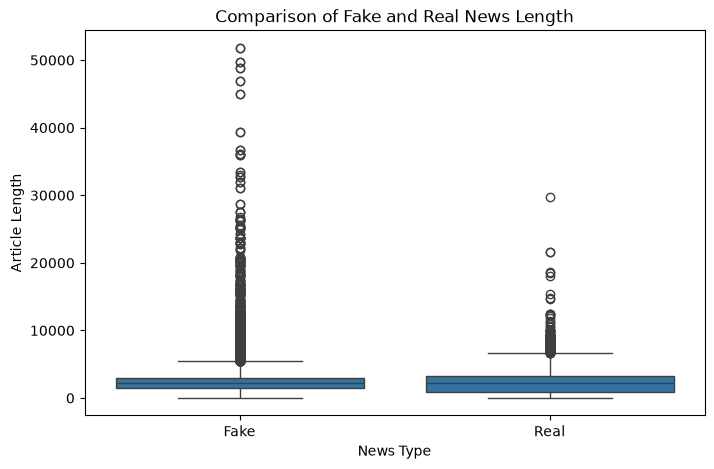

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="text_length",
    data=df
)

plt.xticks([0,1], ["Fake","Real"])

plt.title("Comparison of Fake and Real News Length")

plt.xlabel("News Type")
plt.ylabel("Article Length")

plt.show()

### Observation

The box plot compares the article lengths of fake and real news. It highlights the median, spread, and presence of outliers for both classes. Such comparisons help identify whether article length can contribute to distinguishing fake news from real news.

In [19]:
df.to_csv("../data/news.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [20]:
df["content"] = df["title"] + " " + df["text"]

df[["title", "content"]].head()

,title,content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,Ben Stein Calls Out 9th Circuit Court: Committ...
1,Trump drops Steve Bannon from National Securit...,Trump drops Steve Bannon from National Securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,Puerto Rico expects U.S. to lift Jones Act shi...
3,OOPS: Trump Just Accidentally Confirmed He Le...,OOPS: Trump Just Accidentally Confirmed He Le...
4,Donald Trump heads for Scotland to reopen a go...,Donald Trump heads for Scotland to reopen a go...


# Conclusion

The exploratory data analysis provided valuable insights into the Fake and Real News dataset.

### Key Findings

- The dataset contains both fake and real news articles.
- No missing values were found in the dataset.
- The fake and real datasets were successfully merged and shuffled.
- The dataset is reasonably balanced for machine learning.
- Political news is the most common subject.
- News article lengths vary considerably across the dataset.
- The processed dataset has been saved for further preprocessing and model training.

The next stage of the project involves text preprocessing, feature extraction using TF-IDF, and training multiple machine learning models for fake news detection.

# Text Preprocessing

## Objective

Machine learning algorithms cannot directly process raw text data. Therefore, the news articles need to be cleaned and standardized before feature extraction and model training.

The preprocessing steps include:

- Converting text to lowercase
- Removing URLs
- Removing punctuation
- Removing numbers
- Removing stopwords
- Applying stemming

These transformations help reduce noise and improve the quality of the textual data.

In [21]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

## Download Required NLTK Resources

The Natural Language Toolkit (NLTK) provides a collection of text processing utilities. In this project, we use the English stopword corpus to remove commonly occurring words that do not contribute significantly to the meaning of the text.

In [22]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Initialize Stopwords and Stemmer

Stopwords are common words such as *the*, *is*, *and*, and *of* that usually do not add significant meaning to a sentence.

A stemming algorithm reduces words to their root form, allowing similar words (such as *running*, *runs*, and *ran*) to be treated as the same feature.

In [23]:
stop_words = set(stopwords.words("english"))

stemmer = PorterStemmer()

print("Stopwords and Stemmer initialized successfully!")

Stopwords and Stemmer initialized successfully!


## Create a Text Preprocessing Function

A reusable preprocessing function is created to clean every news article consistently before feature extraction.

The preprocessing function performs the following operations:

- Convert text to lowercase
- Remove URLs
- Remove punctuation
- Remove numbers
- Remove extra spaces
- Remove stopwords
- Apply stemming

In [24]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords and apply stemming
    cleaned_words = []

    for word in words:
        if word not in stop_words:
            cleaned_words.append(stemmer.stem(word))

    return " ".join(cleaned_words)

## Test the Preprocessing Function

Before applying preprocessing to the complete dataset, the function is tested on a sample news article to verify that the text is cleaned correctly.

In [25]:
sample_text = df["text"].iloc[0]

print("Original Text:\n")
print(sample_text[:500])

print("\n" + "="*80 + "\n")

print("Processed Text:\n")
print(preprocess_text(sample_text)[:500])

Original Text:

21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein


Processed Text:

st centuri wire say ben stein reput professor pepperdin univers also hollywood fame appear tv show film ferri bueller day made provoc statement judg jeanin pirro show recent discuss halt impos presid trump execut order travel stein refer judgement th circuit court washington state coup tat execut branch constitut stein went call judg seattl polit puppet judiciari polit pawn watch interview complet statement note stark contrast rhetor leftist media pundit negle

## Apply Text Preprocessing

The preprocessing function is applied to every news article in the dataset to create a new column named **clean_text**. This cleaned text will be used for feature extraction and model training.

In [26]:
df["clean_text"] = df["content"].apply(preprocess_text)

print("Text preprocessing completed successfully!")

Text preprocessing completed successfully!


## Compare Original and Cleaned Text

The following output compares the original news article with its cleaned version to verify that preprocessing has been applied correctly.

In [27]:
df[["text", "clean_text"]].head()

,text,clean_text
0,"21st Century Wire says Ben Stein, reputable pr...",ben stein call th circuit court commit ‘coup d...
1,WASHINGTON (Reuters) - U.S. President Donald T...,trump drop steve bannon nation secur council w...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,puerto rico expect us lift jone act ship restr...
3,"On Monday, Donald Trump once again embarrassed...",oop trump accident confirm leak isra intellig ...
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",donald trump head scotland reopen golf resort ...


### Observation

The preprocessing function successfully cleaned the news articles by removing unnecessary characters, punctuation, numbers, URLs, and common stopwords. A new column named **clean_text** has been created, which will be used for feature extraction and machine learning model training.

In [28]:
df.to_csv("../data/clean_news.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Feature Extraction

## Objective

Machine learning algorithms cannot process textual data directly. Therefore, the cleaned news articles are transformed into numerical feature vectors using **Term Frequency–Inverse Document Frequency (TF-IDF)**.

TF-IDF assigns greater importance to words that are frequent within a document but less frequent across the dataset, helping improve the performance of text classification models.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

## Transform Text Using TF-IDF

The cleaned news articles are converted into numerical feature vectors using the TF-IDF vectorizer.

To reduce computational complexity while preserving important information, the vocabulary is limited to the **5,000 most informative words**.

In [30]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_text"])

y = df["label"]

print("Feature extraction completed successfully!")

Feature extraction completed successfully!


## Verify the Feature Matrix

The dimensions of the feature matrix and target variable are displayed to confirm that the text data has been successfully transformed into numerical vectors.

In [31]:
print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape : (44898, 5000)
Target Variable Shape: (44898,)


## Split the Dataset

The dataset is divided into training and testing sets.

- **80%** of the data is used for training.
- **20%** of the data is reserved for testing.

This enables the trained models to be evaluated on unseen data.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 35918
Testing Samples  : 8980


### Observation

The cleaned news articles have been successfully transformed into TF-IDF feature vectors and divided into training and testing sets. The training set will be used to train machine learning models, while the testing set will be used to evaluate their performance.

# Machine Learning Model Training

## Objective

The transformed TF-IDF features are used to train multiple machine learning classification models.

Training multiple models allows us to compare their performance and identify the most suitable algorithm for fake news detection.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Logistic Regression

Logistic Regression is a widely used linear classification algorithm. It is often considered a strong baseline model for text classification problems due to its efficiency and high performance with TF-IDF features.

In [34]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Accuracy : 0.9871937639198218
Precision: 0.9819067501739736
Recall   : 0.9913348946135832
F1 Score : 0.9865982985666006


## Confusion Matrix for Logistic Regression

A confusion matrix provides a detailed summary of the model's predictions by showing the number of correctly and incorrectly classified news articles.

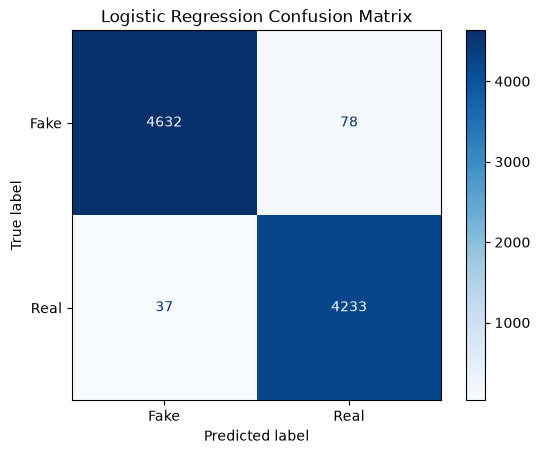

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["Fake", "Real"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

## Multinomial Naive Bayes

Multinomial Naive Bayes is a probabilistic classification algorithm that is widely used for text classification tasks. It performs particularly well with TF-IDF and Bag-of-Words feature representations due to its simplicity and computational efficiency.

In [36]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall   :", recall_score(y_test, nb_pred))
print("F1 Score :", f1_score(y_test, nb_pred))

Accuracy : 0.933184855233853
Precision: 0.9289387564282375
Recall   : 0.9306791569086651
F1 Score : 0.9298081422554983


## Confusion Matrix for Multinomial Naive Bayes

The confusion matrix illustrates the performance of the Multinomial Naive Bayes model by comparing the predicted labels with the actual labels.

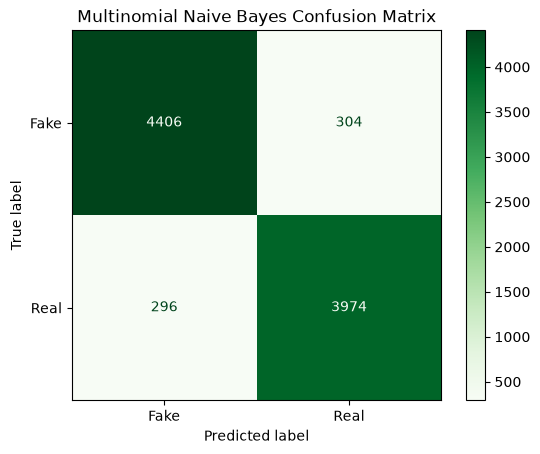

In [37]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_pred,
    display_labels=["Fake", "Real"],
    cmap="Greens"
)

plt.title("Multinomial Naive Bayes Confusion Matrix")
plt.show()

## Decision Tree Classifier

Decision Trees classify data by learning a series of decision rules from the training dataset. They are easy to interpret and can capture non-linear relationships between features.

In [38]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))

Accuracy : 0.9955456570155902
Precision: 0.9974129821260583
Recall   : 0.993208430913349
F1 Score : 0.9953062661347102


## Confusion Matrix for Decision Tree

The confusion matrix provides a detailed evaluation of the Decision Tree classifier by displaying correctly and incorrectly classified news articles.

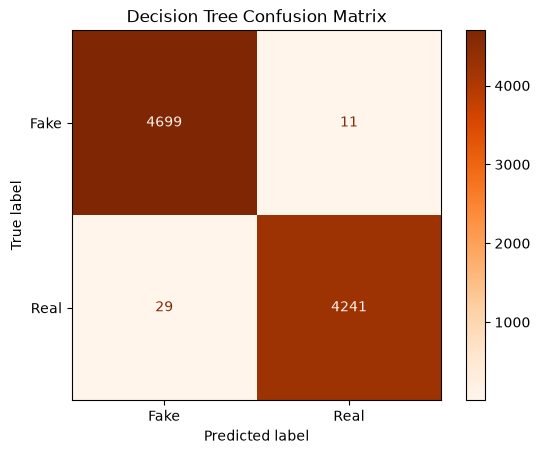

In [39]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    display_labels=["Fake", "Real"],
    cmap="Oranges"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is known for its robustness and ability to handle complex datasets.

In [40]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.9976614699331848
Precision: 0.9974244907515805
Recall   : 0.9976580796252927
F1 Score : 0.9975412715138743


## Confusion Matrix for Random Forest

The confusion matrix visualizes the performance of the Random Forest classifier by comparing the predicted labels with the actual labels.

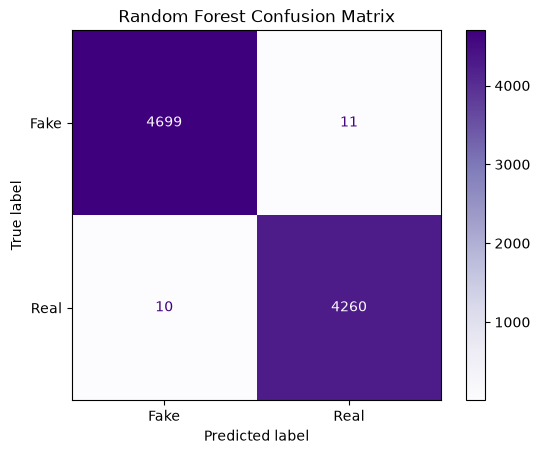

In [41]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Fake", "Real"],
    cmap="Purples"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

## Support Vector Machine (Linear SVM)

Support Vector Machines (SVM) are highly effective for text classification tasks. Using a linear kernel with TF-IDF features often produces excellent classification performance while maintaining good generalization.

In [42]:
svm = LinearSVC(random_state=42)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))

Accuracy : 0.994543429844098
Precision: 0.9927620826523464
Recall   : 0.9957845433255269
F1 Score : 0.9942710160177716


## Confusion Matrix for Support Vector Machine

The confusion matrix illustrates the prediction performance of the Support Vector Machine by showing the correctly and incorrectly classified news articles.

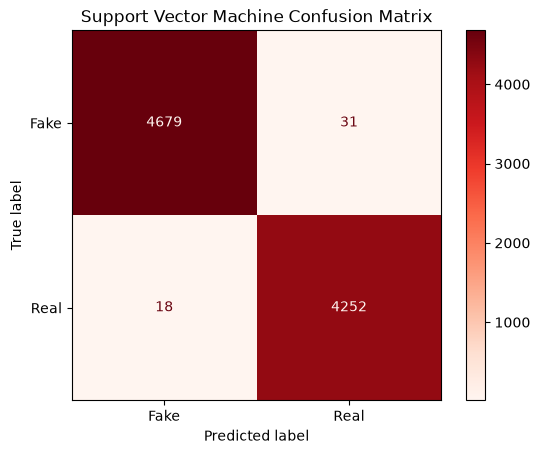

In [43]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    display_labels=["Fake", "Real"],
    cmap="Reds"
)

plt.title("Support Vector Machine Confusion Matrix")
plt.show()

# Model Performance Comparison

## Objective

After training multiple machine learning models, their performance is compared using four evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-Score

Comparing these metrics helps identify the most effective model for fake news detection.

In [44]:
results = {
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest",
        "Linear SVM"
    ],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, nb_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred)
    ],

    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, nb_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred)
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, nb_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred)
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.987194,0.981907,0.991335,0.986598
1,Naive Bayes,0.933185,0.928939,0.930679,0.929808
2,Decision Tree,0.995546,0.997413,0.993208,0.995306
3,Random Forest,0.997661,0.997424,0.997658,0.997541
4,Linear SVM,0.994543,0.992762,0.995785,0.994271


## Visual Comparison of Model Accuracy

The following bar chart compares the accuracy achieved by each machine learning model on the test dataset. Higher accuracy indicates better overall classification performance.

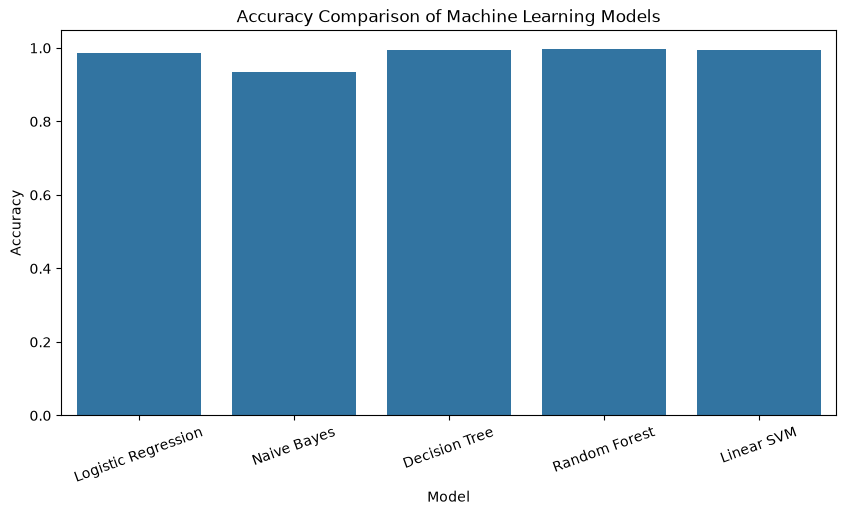

In [45]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.xticks(rotation=20)

plt.title("Accuracy Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.show()

## Visual Comparison of Precision

Precision measures the proportion of news articles predicted as real that are actually real. A higher precision indicates fewer false positive predictions.

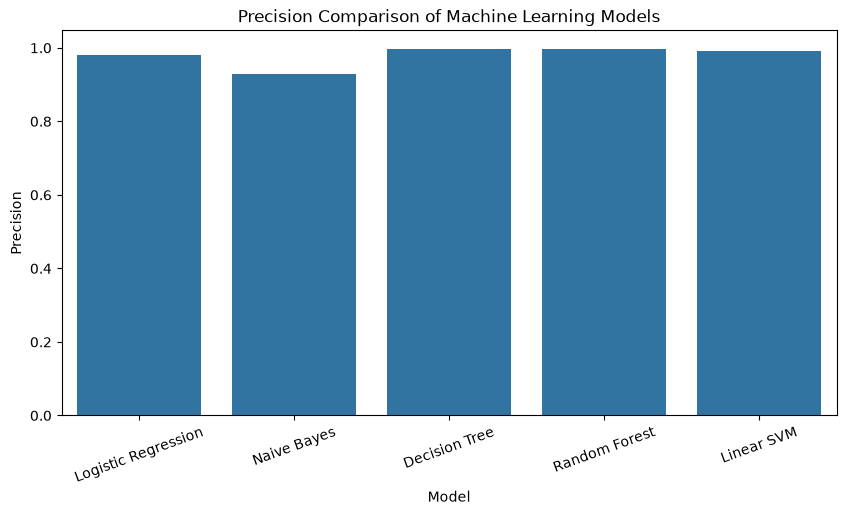

In [46]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Precision",
    data=results_df
)

plt.xticks(rotation=20)

plt.title("Precision Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Precision")

plt.show()

## Visual Comparison of Recall

Recall measures the proportion of actual real news articles that were correctly identified by the model. Higher recall indicates fewer false negative predictions.

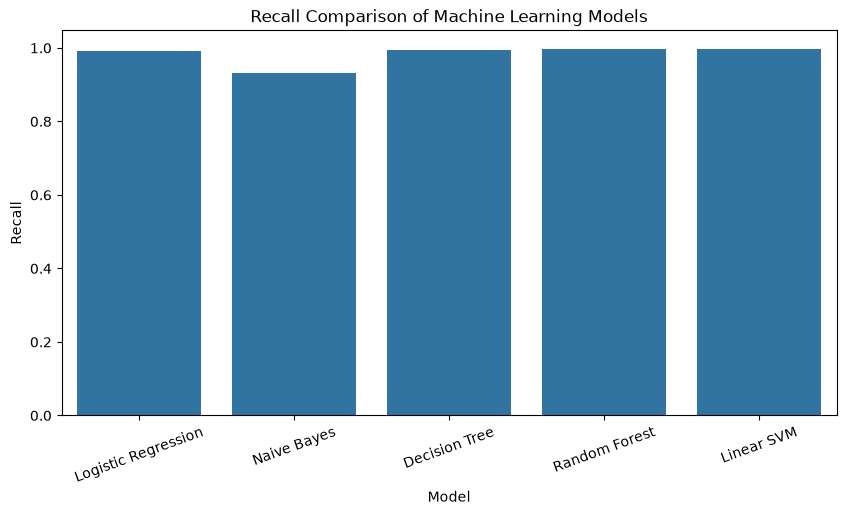

In [47]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Recall",
    data=results_df
)

plt.xticks(rotation=20)

plt.title("Recall Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Recall")

plt.show()

## Visual Comparison of F1-Score

The F1-score is the harmonic mean of precision and recall. It provides a balanced measure of a model's performance, especially when both false positives and false negatives are important.

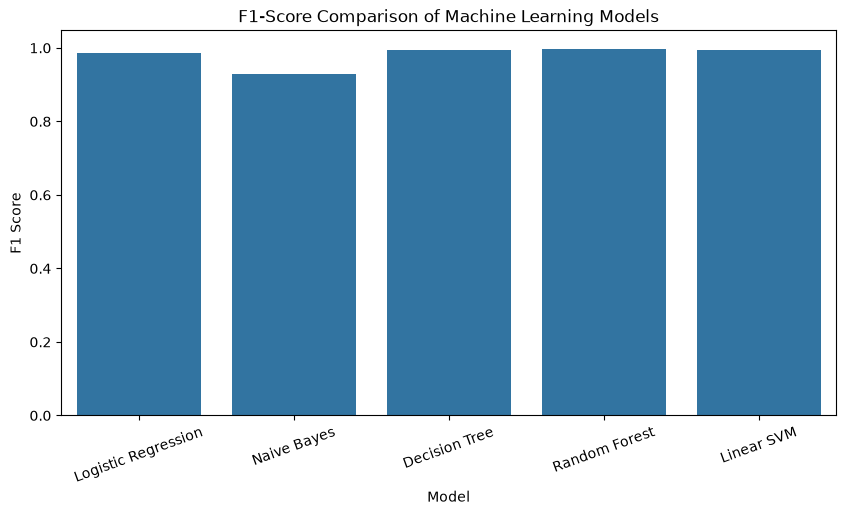

In [48]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="F1 Score",
    data=results_df
)

plt.xticks(rotation=20)

plt.title("F1-Score Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.show()

## Overall Performance Summary

The comparison table and visualizations indicate the relative performance of each machine learning model based on Accuracy, Precision, Recall, and F1-Score.

The best-performing model can be selected for deployment based on these evaluation metrics.

In [49]:
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.997661,0.997424,0.997658,0.997541
2,Decision Tree,0.995546,0.997413,0.993208,0.995306
4,Linear SVM,0.994543,0.992762,0.995785,0.994271
0,Logistic Regression,0.987194,0.981907,0.991335,0.986598
1,Naive Bayes,0.933185,0.928939,0.930679,0.929808


# Model Saving

## Objective

After evaluating multiple machine learning models, the best-performing model is saved for future use.

The trained **Linear Support Vector Machine (SVM)** model and the **TF-IDF vectorizer** are stored using the `joblib` library. These saved files will later be loaded into the Streamlit application to classify new news articles without retraining the model.

In [50]:
import joblib
import os

## Create the Models Directory

A dedicated folder is created to store the trained machine learning model and the TF-IDF vectorizer. This keeps the project organized and simplifies deployment.

In [51]:
os.makedirs("../models", exist_ok=True)

print("Models folder created successfully!")

Models folder created successfully!


## Save the Trained Model and TF-IDF Vectorizer

The trained Linear SVM model and the fitted TF-IDF vectorizer are saved as serialized files using the `joblib` library.

These files will be loaded directly by the web application for making predictions on new news articles.

In [52]:
joblib.dump(rf, "../models/fake_news_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!


## Verify Saved Files

The contents of the models directory are displayed to confirm that the trained model and TF-IDF vectorizer have been saved successfully.

In [53]:
os.listdir("../models")

['fake_news_model.pkl', 'tfidf_vectorizer.pkl']

In [56]:
df[df["label"] == 1]["text"].iloc[0]

'WASHINGTON (Reuters) - U.S. President Donald Trump removed his chief strategist Steve Bannon from the National Security Council on Wednesday, reversing his controversial decision early this year to give a political adviser an unprecedented role in security discussions. Trump’s overhaul of the NSC, confirmed by a White House official, also elevated General Joseph Dunford, chairman of the Joint Chiefs of Staff and Dan Coats, the director of National Intelligence who heads all 17 U.S. intelligence agencies. The official said the change moves the NSC “back to its core function of what it’s supposed to do.” It also appears to mark a victory for national security adviser H.R. McMaster, who had told some national security experts he felt he was in a “battle to the death” with Bannon and others on the White House staff. Vice President Mike Pence said Bannon would continue to play an important role in policy and played down the shake-up as routine. “This is just a natural evolution to ensure t

In [57]:
df[df["label"] == 0]["text"].iloc[0]

'21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on President Trump s Executive Order on travel. Stein referred to the judgement by the 9th Circuit Court in Washington state as a  Coup d tat against the executive branch and against the constitution.  Stein went on to call the Judges in Seattle  political puppets  and the judiciary  political pawns. Watch the interview below for the complete statements and note the stark contrast to the rhetoric of the leftist media and pundits who neglect to note that no court has ever blocked any Presidential orders in immigration in the past or discuss the legal efficacy of the halt or the actual text of the Executive Order.READ MORE TRUMP NEWS AT: 21st Century Wire Trump FilesSUPPORT OUR WORK BY SUBSCRIBING &